In [36]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV

In [14]:
data = fetch_california_housing(as_frame=True)

In [15]:
#1

In [16]:
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
#2

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [19]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [20]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
scaler = MinMaxScaler()
df['MedInc_normalized'] = scaler.fit_transform(df[['MedInc']])

In [22]:
df[['MedInc', 'MedInc_normalized']].head()

,MedInc,MedInc_normalized
0,8.3252,0.539668
1,8.3014,0.538027
2,7.2574,0.466028
3,5.6431,0.354699
4,3.8462,0.230776


In [ ]:
#3

In [24]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 9), (4128, 9), (16512,), (4128,))

In [ ]:
#4-5

In [25]:
reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

score = reg_model.score(X_test, y_test)
score

0.5757877060324513

In [26]:
y_pred = reg_model.predict(X_test)
y_pred[:5], y_test[:5].values

(array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725]),
 array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   ]))

In [ ]:
#6

In [30]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

y_tree_pred = tree_model.predict(X_test)

tree_score = tree_model.score(X_test, y_test)
tree_score, y_tree_pred[:5], y_test[:5].values

(0.6129559128048254,
 array([0.417  , 1.203  , 5.00001, 2.225  , 2.257  ]),
 array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   ]))

In [ ]:
#7

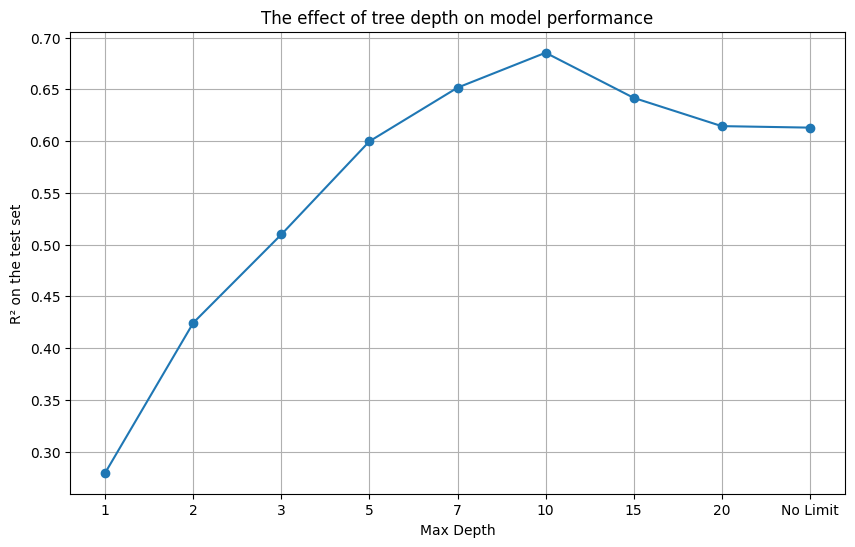

In [34]:
max_depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
scores = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    scores.append(tree.score(X_test, y_test))  # R^2 на тесте

labels = ['No Limit' if d is None else d for d in max_depths]

plt.figure(figsize=(10,6))
plt.plot(labels, scores, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("R² on the test set")
plt.title("The effect of tree depth on model performance")
plt.grid(True)
plt.show()

In [32]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_

best_score = best_tree.score(X_test, y_test)

best_pred = best_tree.predict(X_test)

grid_search.best_params_, best_score, best_pred[:5], y_test[:5].values

({'max_depth': 10, 'min_samples_split': 20},
 0.6937496953891551,
 array([0.55230097, 0.72655118, 4.96858   , 2.25404687, 2.04551471]),
 array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   ]))

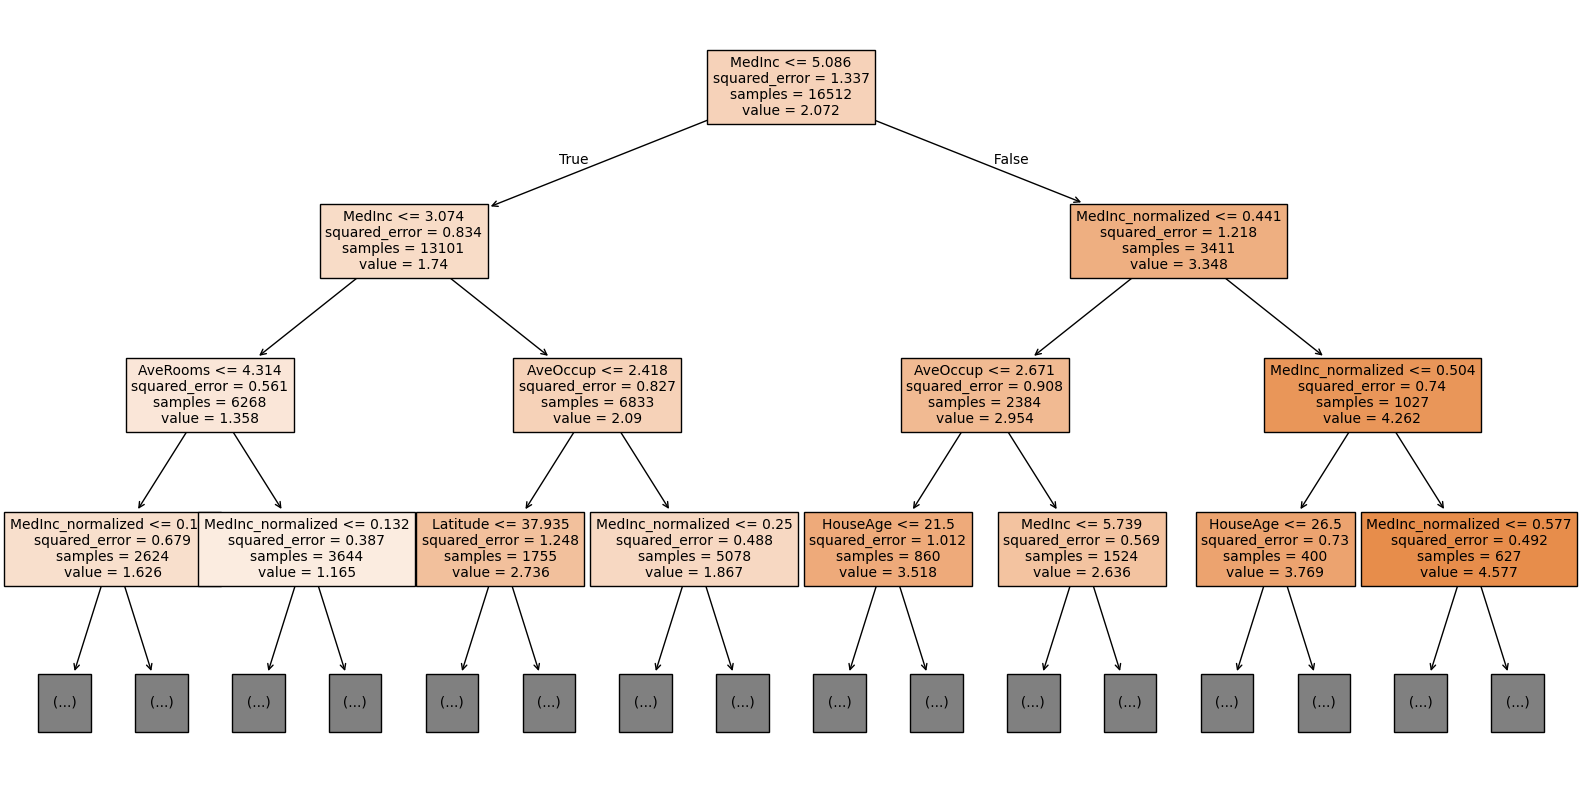

In [37]:
best_depth = 10
best_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)

best_score = best_tree.score(X_test, y_test)
best_pred = best_tree.predict(X_test)

best_score, best_pred[:5], y_test[:5].values

plt.figure(figsize=(20,10))
plot_tree(best_tree, max_depth=3, feature_names=X.columns, filled=True, fontsize=10)
plt.show()

In [ ]:
#8

In [38]:
# Linear regression showed moderate score. 
# It handles linear relationships well but does not capture complex nonlinear interactions between features and the target variable.
# The decision tree captured nonlinear relationships better, which is why its accuracy is higher.